# Lab 1 - Exploring Table Data

You are to perform preprocessing and exploratory analysis of a data set: exploring the statistical summaries of the features, visualizing the attributes, and addressing data quality. This report is worth 10% of the final grade. Please upload a report (one per team) with all code used, visualizations, and text in a rendered Jupyter notebook. Any visualizations that cannot be embedded in the notebook, please provide screenshots of the output. Only the rendered HTML notebook is acceptable. 

------

Prediction: Will a telecom customer churn (Yes/No)?

Questions
- Is it more likely for men or women to churn when expressed as a percentage?
- Are older or younger people more likely to churn (senior citizens vs non senior citizens)?
- Churn rate by monthly cost and internet service

------

## 1. Business Understanding

### 1.1 Business Understanding

The main question we hope to answer with our analysis is whether a Telco customer will churn (discontinue their service with a provider). Churn is one of the most important challenges in the telecommunications industry, as customer acquisition costs are high and the industry is highly competitive. Retaining a new customer is estimated to be from 5 to 25 times cheaper than acquiring a new one, due to the lower marketing, sales, and onboarding costs, meaning that making an effective churn prediction can greatly impact the profitability of a company. As the dataset description says: “The data set includes information about:
- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents”

Analyzing these features will allow us to determine which factors most strongly influence customer churn or retention.

The end goal of analyzing this dataset would be to classify whether a customer is likely to churn, while also providing actionable insights. 

Beyond just the prediction, the analysis can guide business strategy, such as:
- Encouraging customers to switch to more long-term contracts
- Bundling internet and support services
- Offering incentives to customers with higher monthly charges
- Promoting auto-pay enrollment to lower attrition rates

### 1.2 Measure of Success

Success in this context is more than just base accuracy. Because churn prediction is either “yes or no”, a binary classification problem, a model that always predicts “no churn” could already be at a 70% accuracy, but it would fail to identify at-risk customers. Therefore, we should focus on:
- Recall for churners (minimizing false negatives): Making sure that we correctly flag as many at-risk customers as possible, since losing them directly impacts revenue
- Precision for churners (minimizing false positives): Avoiding the waste of resources for customers who were already unlikely to leave

A churn model would be considered viable for a business if it identifies a majority of churners (>80-85% recall) while keeping false positives at a low number, so that the cost of interventions is outweighed by the value of the customers retained.

Dataset Source: [https://www.kaggle.com/datasets/blastchar/telco-customer-churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

------

## 2. Data Understanding

In [23]:
import pandas as pd

# Load dataset
df = pd.read_csv("/workspace/datasets/Lab1.csv")

# Print shape
print("Shape of dataset:", df.shape)

# Print column names and data types
print("\nColumns and Data Types:")
print(df.dtypes)

Shape of dataset: (7043, 21)

Columns and Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


### 2.1 Data Description

The dataset has 7043 rows and 21 columns. Attributes include customer demographic information, account details, services used, and churn status.

Based on each of the columns and features, these are what we believe should be the corresponding data types:

- customerID → string (identifier, not numeric)

- gender → categorical (Male, Female)

- SeniorCitizen → integer (0/1, could also be categorical Yes/No)

- Partner, Dependents, PhoneService, MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, PaperlessBilling, Churn → categorical (Yes/No, or other categories like “No internet service”)

- InternetService, Contract, PaymentMethod → categorical (e.g., DSL, Fiber optic, etc.)

- tenure → integer (number of months customer stayed)

- MonthlyCharges → float (continuous numeric)

- TotalCharges → float (continuous numeric)


In [24]:
import warnings
warnings.filterwarnings("ignore")

### 2.2 Data Quality

In [25]:
import pandas as pd
import numpy as np

df = pd.read_csv('/workspace/datasets/Lab1.csv')

# renaming columns for consistency
df = df.rename(columns={"customerID": "CustomerId", "gender": "Gender", "tenure": "Tenure"})

df.head()

,CustomerId,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


- Using a heatmap, I am going to see which features/columns have the most missing data or any missing data. Based on that, I will clean the data if needed.
- In the code below:

df.isnull() → creates a DataFrame of the same shape as df where each cell is True if the value is missing (NaN) and False otherwise.

sns.heatmap(df.isnull(), cbar=False) → uses Seaborn’s heatmap to plot this matrix, showing missing values as one color (usually yellow/white) and non-missing values as another (usually dark).

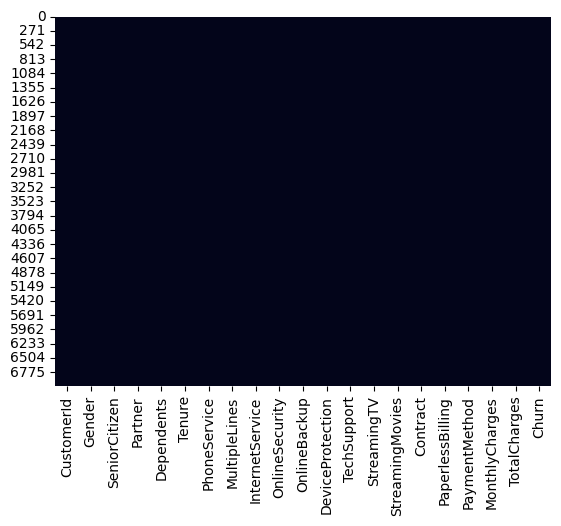

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)
plt.show()

Based on the heat map, it can be conlcuded that there is no missing data

## 3. Data Visualization

### 3.1 Data Distribution (plots & derived meaning/conclusions)

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv('/workspace/datasets/Lab1.csv')

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Overall churn rate
churn_rate = df["Churn"].value_counts(normalize=True)["Yes"]
print(f"Overall churn rate (for curiosity purposes): {churn_rate:.2%}")

# Using a function so I don't have to rewrite the same code 6 times
def churn_summary(col):
    churn_rates = df.groupby(col)["Churn"].value_counts(normalize=True).unstack().fillna(0)
    return churn_rates

Overall churn rate (for curiosity purposes): 26.54%


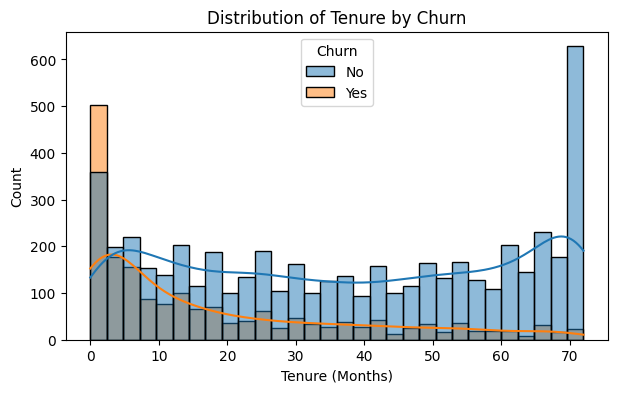

In [28]:
# 1. Histogram of tenure by churn
plt.figure(figsize=(7,4))
sns.histplot(data=df, x="tenure", bins=30, kde=True, hue="Churn")
plt.title("Distribution of Tenure by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")
plt.show()

Strong Inverse Relationship: The most striking finding is the strong inverse correlation between tenure and churn. Newer customers (low tenure) are significantly more likely to churn than long-standing customers for IBM Telco. Churn peak during the first month or so but it goes down from 70 months onwards.

- The bars for "Yes" (churned customers) are heavily concentrated on the left side of the graph (0-10 months).

- The bars for "No" (loyal customers) dominate the right side of the graph (30+ months).

- Critical Churn Period: The first 5-10 months appear to be the most critical period for customer retention. A very high proportion of customers who leave do so within this timeframe. This suggests the onboarding process and initial customer experience are crucial for IBM.

- Loyalty Development: After approximately 20-30 months, customers become far more stable and loyal. The rate of churn among these tenured customers is very low. This indicates that if IBM can successfully retain a customer past the initial high-risk period, the customer's lifetime value increases substantially.

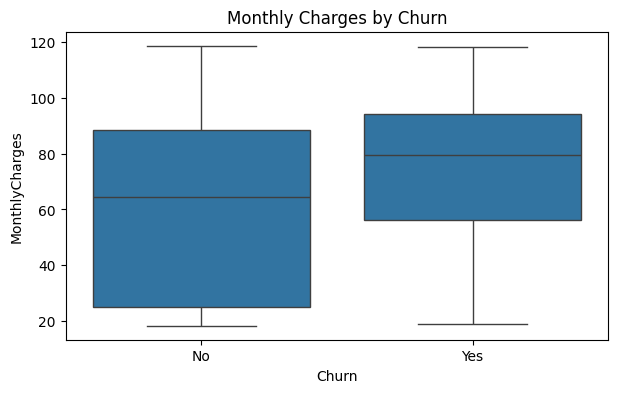

In [29]:
# 2. Boxplot of MonthlyCharges by Churn
plt.figure(figsize=(7,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn")
plt.show()

This visualization reveals a critical financial pattern in customer churn behavior for the telecom company.

Key Finding: 
- Customers who churn have a significantly higher median Monthly Charge than those who stay. This is not just a slight difference; the entire boxplot for "Yes" (churned) is shifted upward, indicating this is a widespread trend.

Strategic Business Context for IBM Telco: 
- This suggests that the company's most lucrative customers—those purchasing premium, high-value bundles (e.g., high-speed internet, multiple lines, streaming TV)—are also the most at risk. They are likely more price-sensitive and have more options from competitors who aggressively target high-spending users.

Conclusion: 
- For retention programs, the Telco should prioritize high-value customers. Initiatives could include personalized loyalty discounts, proactive check-ins on service quality, or exclusive offers to enhance their perceived value and lock them into longer-term contracts.

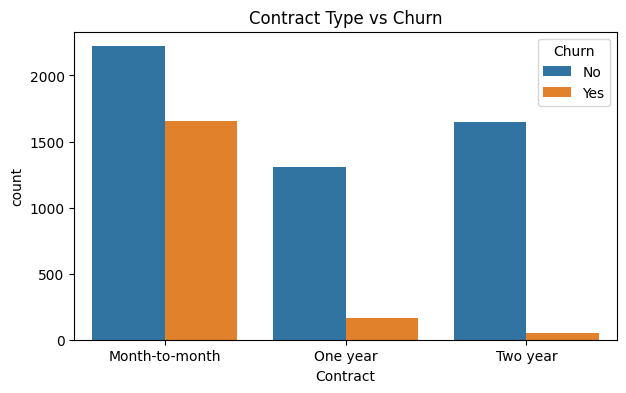


Churn by Contract Type:
 Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


In [30]:
# 3. Countplot of Contract by Churn
plt.figure(figsize=(7,4))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.show()
print("\nChurn by Contract Type:\n", churn_summary("Contract"))

This plot reveals the most decisive factor in customer retention for IBM Telco: the contract length.

Key Finding: Churn is overwhelmingly a problem for month-to-month customers.

- ~43% of month-to-month customers churned.
- Only 11% of one-year and a mere 3% of two-year customers left.

Strategic Context for IBM Telco:
- This highlights a critical vulnerability. While month-to-month contracts offer flexibility to attract customers, they create zero barrier to exit. The near-perfect retention of two-year contract customers demonstrates that long-term commitments are the most effective retention tool.

Conclusion: 
- The telco's primary strategy should be to aggressively incentivize customers to move off month-to-month plans. Retention efforts for at-risk customers should focus on converting them to longer-term contracts through targeted discounts and value-added services, effectively locking in revenue.

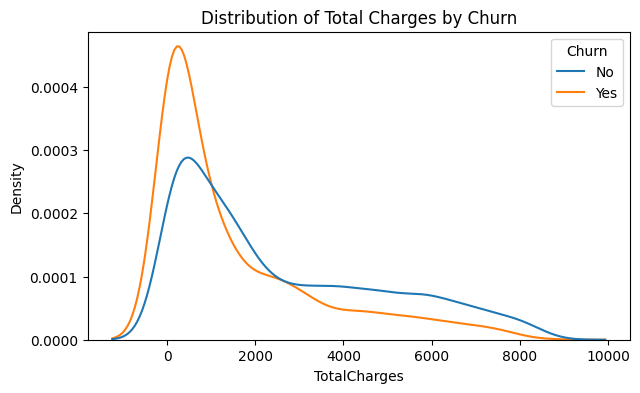

In [31]:
# 4. KDE plot of TotalCharges by Churn
plt.figure(figsize=(7,4))
sns.kdeplot(data=df, x="TotalCharges", hue="Churn", common_norm=False)
plt.title("Distribution of Total Charges by Churn")
plt.show()

This KDE plot reinforces the narrative from tenure and contract type, showing its direct financial impact.

Key Finding: Customers who churn have a significantly lower lifetime value.

- The distribution for churned customers ("Yes") is heavily concentrated at the very low end of the Total Charges spectrum (peaking near $0).

- The loyal customers ("No") show a much wider distribution, with a dense peak representing established, high-value customers.

Strategic Context for IBM Telco:
- This visualizes the direct revenue loss from churn. The company is failing to monetize and "lock-in" its customer relationships over the long term. The goal of retention programs is to shift customers from the left "Yes" distribution to the right "No" distribution.

Conclusion: 
- The data consistently shows that surviving the initial tenure period and signing a longer contract is the path to high customer lifetime value. Retention efforts must focus on the critical first few months to guide new, at-risk customers toward this profitable path.

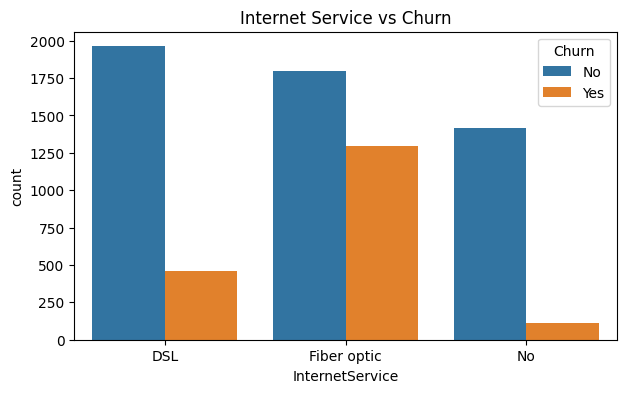


Churn by Internet Service:
 Churn                  No       Yes
InternetService                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No               0.925950  0.074050


In [32]:
# 5. InternetService vs Churn
plt.figure(figsize=(7,4))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet Service vs Churn")
plt.show()
print("\nChurn by Internet Service:\n", churn_summary("InternetService"))

___________________________________
This plot reveals a severe and specific vulnerability in IBM Telco's service offerings.

Key Finding:

- Fiber optic customers have a dangerously high churn rate of ~42%, more than double the rate of DSL customers (19%).

- Customers with no internet service (likely phone-only) have the lowest churn rate at 7%.

Strategic Context for IBM Telco:
This indicates a major issue with the fiber optic product segment. Despite being a premium, high-speed service, it is failing to retain customers. Potential causes may include (based on hypothesis):

- Price: The high cost (correlated with higher MonthlyCharges) may not be perceived as providing good value.

- Competition: The fiber market is likely highly competitive, with rivals easily poaching dissatisfied customers.

- Service Reliability: Technical issues or inconsistent speeds could be leading to dissatisfaction.

Conclusion: 
- The fiber optic customer base represents both a major risk and a significant opportunity. Retention programs must be immediately targeted at this group. Strategies should include competitive pricing analysis, improving service reliability, and enhancing the perceived value of the product to justify its cost.

### 3.2 Interesting Questions

#### Question 1: Is it more likely for men or women to churn when expressed as a percentage?

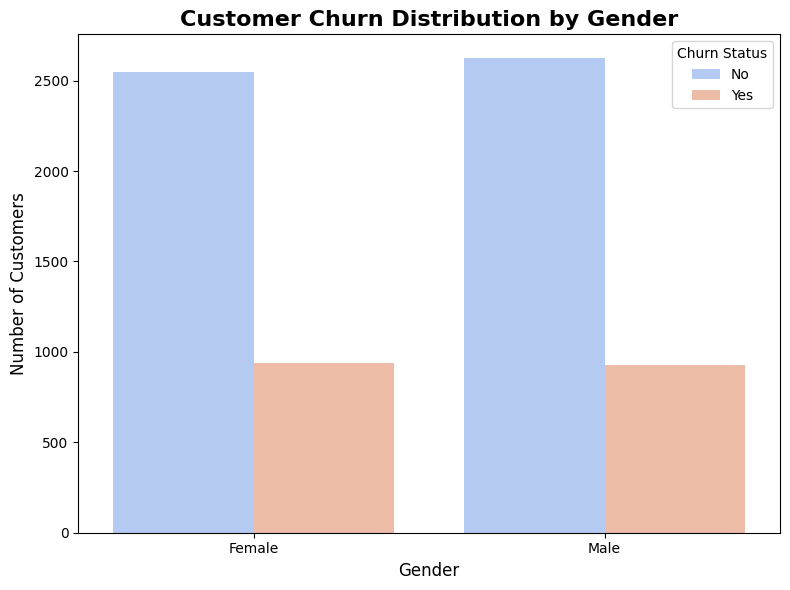

gender
Male      3555
Female    3488
Name: count, dtype: int64

Churn by Gender:
Churn         No       Yes
gender                    
Female  0.730791  0.269209
Male    0.738397  0.261603


In [33]:
# Create countplot for churn by gender
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='gender', hue='Churn', palette='coolwarm')

plt.title('Customer Churn Distribution by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.legend(title='Churn Status', loc='upper right')
plt.tight_layout()
plt.show()


# Count number of males and females
gender_counts = df['gender'].value_counts()
print(gender_counts)

# Print the numerical summary
print("\nChurn by Gender:")
print(churn_summary("gender"))

Business Interpretation: Gender is Not a Driver of Churn

The fact that the churn percentage is virtually identical for both genders (e.g., ~26% for Females and ~27% for Males) is a highly significant and actionable finding for the business.

This means one thing pretty clearly: The reasons customers leave are not tied to their gender, especially since there is roughly the same count of males and females.

#### Question 2: Are older or younger people more likely to churn (senior citizens vs non senior citizens)?

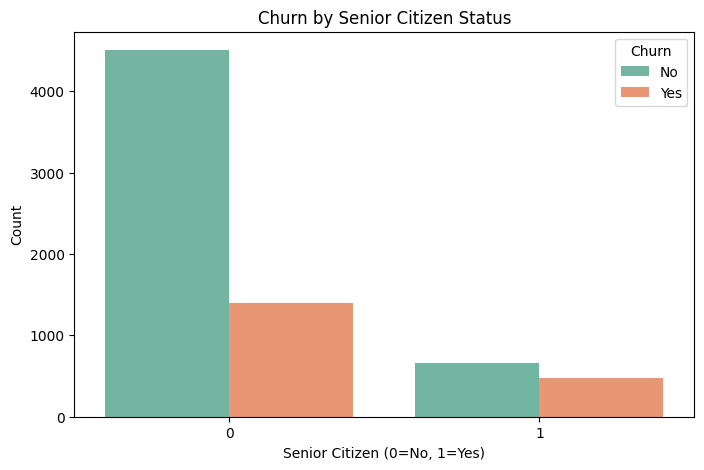


Churn by Senior Citizen:
 Churn                No       Yes
SeniorCitizen                    
0              0.763938  0.236062
1              0.583187  0.416813

Senior Citizen Distribution:


                    Count  Percentage
SeniorCitizen                        
Not Senior Citizen   5901   83.785319
Senior Citizen       1142   16.214681


In [34]:
#6 SeniorCitizen status vs Churn
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette='Set2')
plt.title('Churn by Senior Citizen Status')
plt.xlabel('Senior Citizen (0=No, 1=Yes)')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.show()
print("\nChurn by Senior Citizen:\n", churn_summary("SeniorCitizen"))


# ** Number of people who are or aren't senior citizens **

senior_counts = df['SeniorCitizen'].value_counts()
senior_percentages = df['SeniorCitizen'].value_counts(normalize=True) * 100

# Create a summary DataFrame
senior_summary = pd.DataFrame({
    'Count': senior_counts,
    'Percentage': senior_percentages
})
senior_summary.index = senior_summary.index.map({0: 'Not Senior Citizen', 1: 'Senior Citizen'})

print("\nSenior Citizen Distribution:")
print("\n")
print(senior_summary)

This count plot identifies a specific customer demographic that requires immediate and targeted retention efforts.

Key Finding:

- Senior citizens have a churn rate of 42%, nearly double the rate of non-seniors (24%).

Strategic Context for IBM Telco:

This significant disparity suggests that the company's service offerings, support, or marketing are not effectively meeting the needs of older adults. Potential drivers include:

- Usability: Services or billing platforms may be too complex.

- Support: Senior citizens may require more hands-on customer support that is not currently adequate.

- Price Sensitivity: Those on fixed incomes may be more sensitive to price increases.

Conclusion: 
- Senior citizens are a vulnerable segment with disproportionately high churn. IBM Telco must develop senior-specific retention programs, which could include dedicated support lines, simplified plans, or senior discounts to improve loyalty and reduce the 42% defection rate. At the same time though, senior citizens only compose of less than a 20% of total customers (which mostly aren't senior citizens).



#### Question 3: Churn rate by monthly cost and internet service

##### Based on the data visualizations and conclusions from 3.1, we know that customers with high MonthlyCharges and those with Fiber optic service churn at alarming rates. On the other hand, those with low MonthlyCharges and no internet service don't churn (leave). For this question, we will visualize the differences in churn rate for either customer demographic. 

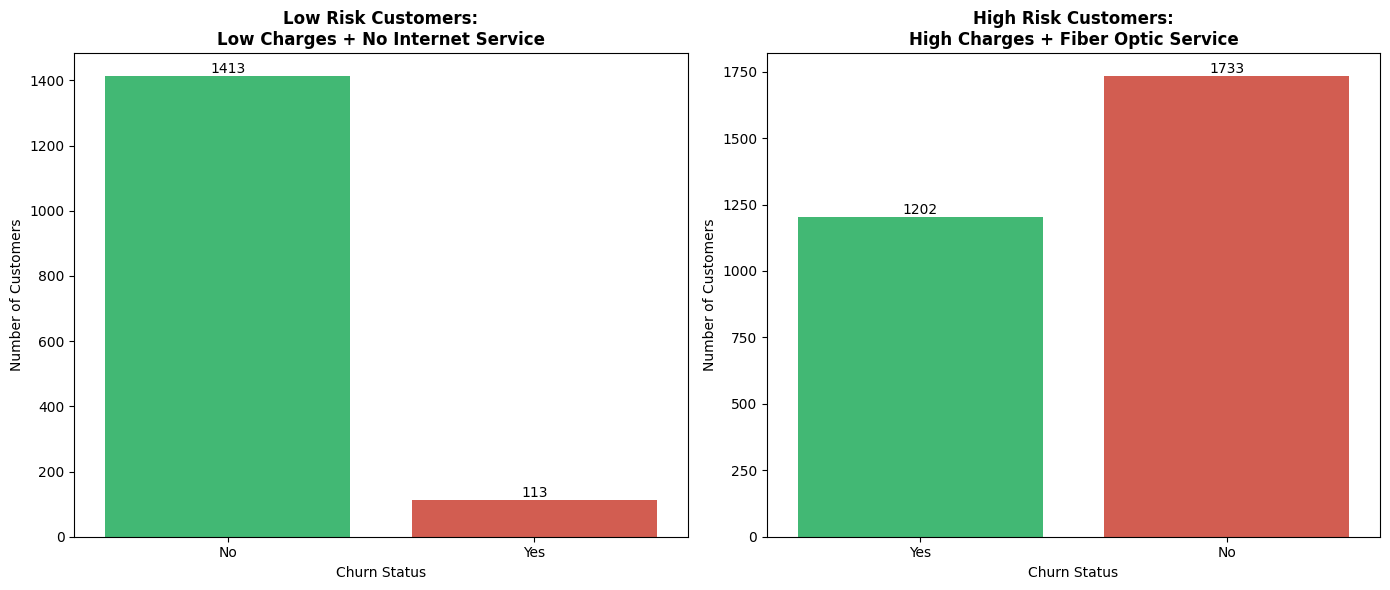

LOW RISK GROUP SUMMARY:
Total customers: 1526
Churned: 113
Churn rate: 7.4%
Average monthly charges: $21.08

HIGH RISK GROUP SUMMARY:
Total customers: 2935
Churned: 1202
Churn rate: 41.0%
Average monthly charges: $92.70


In [35]:
# Define the two customer groups
# Group 1: Low risk - Low monthly charges AND No internet service
low_risk = df[(df['MonthlyCharges'] < df['MonthlyCharges'].median()) & (df['InternetService'] == 'No')]

# Group 2: High risk - High monthly charges AND Fiber optic internet service
high_risk = df[(df['MonthlyCharges'] > df['MonthlyCharges'].median()) & (df['InternetService'] == 'Fiber optic')]

# Create the count plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Low Risk Group
sns.countplot(data=low_risk, x='Churn', ax=ax1, palette=['#2ecc71', '#e74c3c'])
ax1.set_title('Low Risk Customers:\nLow Charges + No Internet Service', fontweight='bold')
ax1.set_xlabel('Churn Status')
ax1.set_ylabel('Number of Customers')

# Add counts on bars for low risk group
for container in ax1.containers:
    for bar in container:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, 
                f'{int(height)}', ha='center', va='bottom')

# Plot 2: High Risk Group
sns.countplot(data=high_risk, x='Churn', ax=ax2, palette=['#2ecc71', '#e74c3c'])
ax2.set_title('High Risk Customers:\nHigh Charges + Fiber Optic Service', fontweight='bold')
ax2.set_xlabel('Churn Status')
ax2.set_ylabel('Number of Customers')

# Add counts on bars for high risk group
for container in ax2.containers:
    for bar in container:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, height + 0.5, 
                f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print summary statistics
print("LOW RISK GROUP SUMMARY:")
print(f"Total customers: {len(low_risk)}")
print(f"Churned: {(low_risk['Churn'] == 'Yes').sum()}")
print(f"Churn rate: {(low_risk['Churn'] == 'Yes').mean()*100:.1f}%")
print(f"Average monthly charges: ${low_risk['MonthlyCharges'].mean():.2f}")

print("\nHIGH RISK GROUP SUMMARY:")
print(f"Total customers: {len(high_risk)}")
print(f"Churned: {(high_risk['Churn'] == 'Yes').sum()}")
print(f"Churn rate: {(high_risk['Churn'] == 'Yes').mean()*100:.1f}%")
print(f"Average monthly charges: ${high_risk['MonthlyCharges'].mean():.2f}")

Conclusion: 
- Low risk customers do indeed have a lower churn rate than high risk customers.
- This strengthens the findings from 3.1 during the EDA done for seeing trends between features and churn rate.

## 4. Additional Analysis

### 4.1 Chi-Square Test for Independence

In [36]:
from scipy.stats import chi2_contingency
import pandas as pd

target_col = 'Churn'

cat_cols = df.select_dtypes(include=['object', 'category']).columns.drop(target_col)

chi_results = []

for col in cat_cols:
    contingency = pd.crosstab(df[col], df[target_col])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi_results.append({
        'Feature': col,
        'Chi2': round(chi2, 3),
        'Degrees_of_Freedom': dof,
        'p_value': round(p, 4),
        'Dependent?': 'Yes' if p < 0.05 else 'No'
    })

chi_df = pd.DataFrame(chi_results).sort_values('p_value')
chi_df.reset_index(drop=True, inplace=True)
chi_df


,Feature,Chi2,Degrees_of_Freedom,p_value,Dependent?
0,Partner,158.733,1,0.0000,Yes
1,Dependents,189.129,1,0.0000,Yes
2,InternetService,732.310,2,0.0000,Yes
3,OnlineSecurity,849.999,2,0.0000,Yes
4,OnlineBackup,601.813,2,0.0000,Yes
5,DeviceProtection,558.419,2,0.0000,Yes
6,TechSupport,828.197,2,0.0000,Yes
7,StreamingTV,374.204,2,0.0000,Yes
8,StreamingMovies,375.661,2,0.0000,Yes
9,Contract,1184.597,2,0.0000,Yes


### 4.2 Feature Correlation

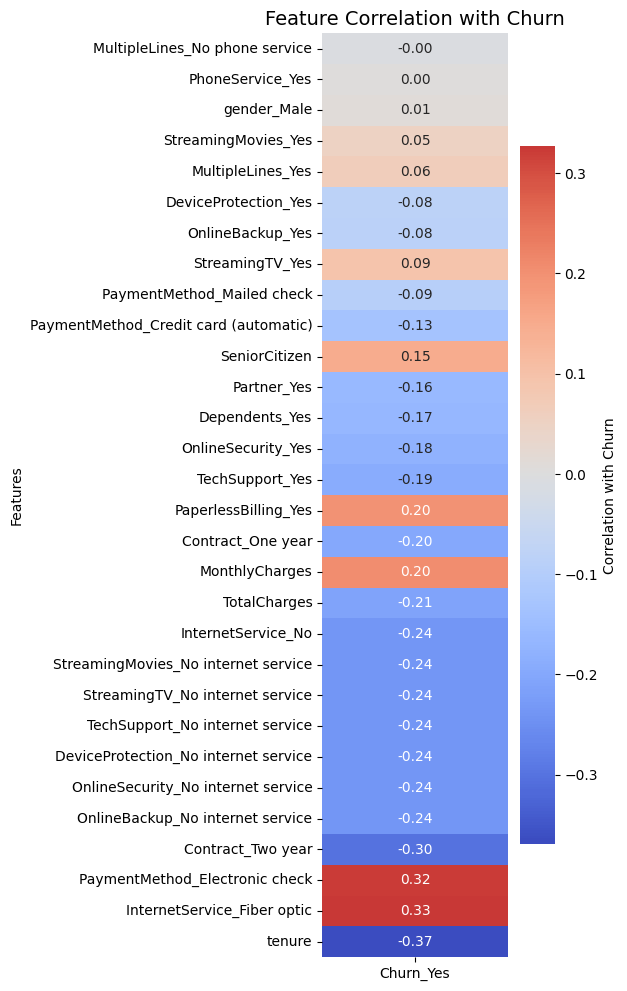

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_clean = df.drop(columns=['customerID'])

df_sample = df_clean.sample(frac=0.3, random_state=42)

df_encoded = pd.get_dummies(df_sample, drop_first=True)

target_corr = (
    df_encoded.corr()['Churn_Yes']
    .drop('Churn_Yes')
    .sort_values(key=abs)
)

plt.figure(figsize=(3, len(target_corr) * 0.4))
sns.heatmap(
    target_corr.to_frame(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Correlation with Churn"}
)
plt.title("Feature Correlation with Churn", fontsize=14)
plt.ylabel("Features")
plt.xlabel("")
plt.tight_layout()
plt.show()
